This notebook produces plots of the results from running cultivation_sweep_h_error.py, which simulates cultivation (no escape) with Clifford proxies using error models where the gates all have fixed generator infidelity, but varying amount of coherent error.

In [37]:
import pickle
import numpy as np
from matplotlib import pyplot as plt

In [23]:
lers = {}
p_keeps = {}
finished_hs = {}

plt.rcParams['font.size'] = 14

In [24]:
h_fractions = np.linspace(1,0, num=20) #np.linspace(0.35,0, num=20) #np.linspace(1,0, num=20) #np.linspace(0.35,0, num=20)
inject_style='unitary'
strength= 1#1.6#1.2#
j=0
lers[inject_style] = []
p_keeps[inject_style] = []
finished_hs[inject_style] = []
for h_fraction in h_fractions:
    lers_this_h = []
    p_keeps_this_h = []
    for j in range(100):
        try:
            with open(f'cultivation_data/cultiv_h_sweep_{inject_style}_{h_fraction}_{strength}_run_{j}_test.pkl', 'rb') as f: #_more_points
                res = pickle.load(f)
            f.close()
            p_keeps_this_h.append(res['frac_kept'])
            lers_this_h.append(res['ler'])
        except:
            pass #print(h_fraction)
    p_keeps[inject_style].append(np.mean(p_keeps_this_h))
    lers[inject_style].append(np.mean(lers_this_h))
    finished_hs[inject_style].append(h_fraction)

In [25]:
h_fractions = np.linspace(1,0, num=20) #np.linspace(0.35,0, num=20) #np.linspace(1,0, num=20) #np.linspace(0.35,0, num=20)
inject_style='degenerate'
strength= 1.6#1.2#
j=0
lers[inject_style] = []
p_keeps[inject_style] = []
finished_hs[inject_style] = []
for h_fraction in h_fractions:
    lers_this_h = []
    p_keeps_this_h = []
    for j in range(10):
        try:
            with open(f'cultivation_data/cultiv_h_sweep_{inject_style}_{h_fraction}_{strength}_run_{j}_test.pkl', 'rb') as f: #_more_points
                res = pickle.load(f)
            f.close()
            p_keeps_this_h.append(res['frac_kept'])
            lers_this_h.append(res['ler'])
        except:
            pass #print(h_fraction)
    p_keeps[inject_style].append(np.mean(p_keeps_this_h))
    lers[inject_style].append(np.mean(lers_this_h))
    finished_hs[inject_style].append(h_fraction)

In [26]:
h_zz_sq = lambda x: (1e-3)*strength*x

In [27]:
finished_hs['degenerate']

[1.0,
 0.9473684210526316,
 0.8947368421052632,
 0.8421052631578947,
 0.7894736842105263,
 0.736842105263158,
 0.6842105263157895,
 0.631578947368421,
 0.5789473684210527,
 0.5263157894736843,
 0.4736842105263158,
 0.42105263157894735,
 0.368421052631579,
 0.3157894736842106,
 0.26315789473684215,
 0.21052631578947367,
 0.1578947368421053,
 0.10526315789473695,
 0.052631578947368474,
 0.0]

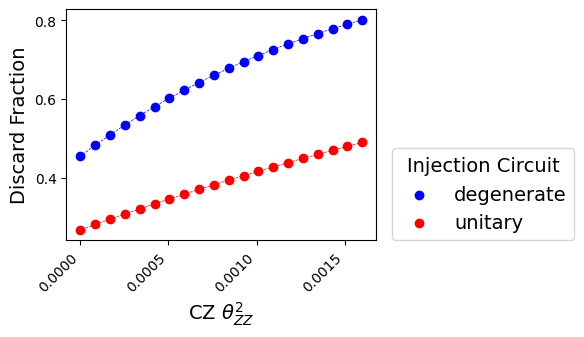

In [28]:
colors = ['blue','red']
plt.figure(figsize=(4,3))
for inject_style, c in zip(['degenerate', 'unitary'], colors):
    plt.scatter([h_zz_sq(h) for h in finished_hs[inject_style]], [1-p for p in p_keeps[inject_style]], label=inject_style, marker='o', color=c)
    plt.plot([h_zz_sq(h) for h in finished_hs[inject_style]], [1-p for p in p_keeps[inject_style]], linewidth=0.5, linestyle='--', color=c)
plt.legend(title='Injection Circuit', loc=(1.05, 0))
#plt.ylim(0.2, 0.7)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10)
plt.ylabel('Discard Fraction')
plt.xlabel(r'''CZ $\theta_{ZZ}^2$''')
plt.show()

Text(0.5, 0, 'CZ $\\theta_{ZZ}^2$')

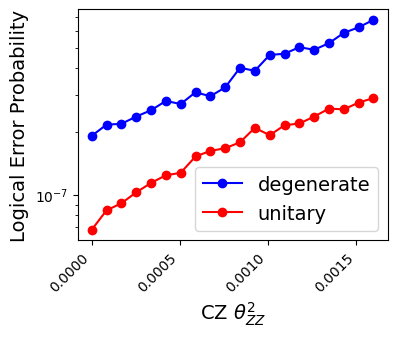

In [29]:
plt.figure(figsize=(4,3))
for inject_style, c in zip(['degenerate', 'unitary'], colors):
    plt.plot([h_zz_sq(h) for h in finished_hs[inject_style]], lers[inject_style], label=inject_style, marker='o', color=c)
    plt.plot([h_zz_sq(h) for h in finished_hs[inject_style]], lers[inject_style], linewidth=0.5, linestyle='--', color=c)
plt.legend(loc='lower right')
plt.ylabel('Logical Error Probability')
plt.yscale('log')
#plt.ylim(1e-7, 2e-6) 
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10)
plt.xlabel(r'''CZ $\theta_{ZZ}^2$''')

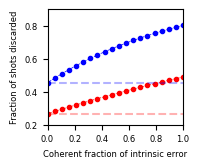

In [36]:
colors = ['blue','red']
plt.figure(figsize=(1.75,1.5))
for inject_style, c in zip(['degenerate', 'unitary'], colors):
    plt.scatter(finished_hs[inject_style], [1-p for p in p_keeps[inject_style]], label=inject_style, marker='.', color=c)
    plt.plot(finished_hs[inject_style], [1-p for p in p_keeps[inject_style]], linewidth=0.5, linestyle='--', color=c)
    plt.axhline(1-p_keeps[inject_style][-1], color=c, linestyle='--', alpha=0.3, label='Pauli stochastic model result')
#plt.legend(fontsize=6)
plt.xticks([0,0.2,0.4,0.6,0.8,1],fontsize=6)
plt.yticks([0.2,0.4,0.6,0.8],fontsize=6)
plt.ylim(0.2,0.9)
plt.xlim(0,1)
plt.ylabel('Fraction of shots discarded',fontsize=6)
plt.xlabel('Coherent fraction of intrinsic error',fontsize=6)
#plt.tight_layout()
plt.savefig('cultiv_rejection.pdf')

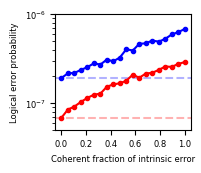

In [34]:
plt.figure(figsize=(1.75,1.5))
for inject_style, c in zip(['degenerate', 'unitary'], colors):
    plt.plot(finished_hs[inject_style], lers[inject_style], label=inject_style, marker='.', color=c)
    plt.plot(finished_hs[inject_style], lers[inject_style], linewidth=0.5, linestyle='--', color=c)
    plt.axhline(lers[inject_style][-1], color=c, linestyle='--', alpha=0.3, label='Pauli stochastic model result')
#plt.legend(fontsize=6)
plt.xticks([0,0.2,0.4,0.6,0.8,1],fontsize=6)
plt.yticks(fontsize=6)
plt.ylabel('Logical error probability',fontsize=6)
plt.yscale('log')
plt.ylim(5e-8,1e-6)
plt.xlabel('Coherent fraction of intrinsic error',fontsize=6)
#plt.tight_layout()
plt.savefig('cultiv_error_rate.pdf')

In [20]:
h_fraction=h_fractions[0]
with open(f'cultivation_data/cultiv_h_sweep_{inject_style}_{h_fraction}_{strength}_run_{j}_test.pkl', 'rb') as f:
    res2 = pickle.load(f)
f.close()

In [21]:
res2['dem']

Counter({'010000000000000000010': 0.09894600413439676,
         '000000000000000001000': 0.062159503100797577,
         '000000110000001000000': 0.042404085572798254,
         '000010000000000010000': 0.03947083505599865,
         '000000100000001010000': 0.03947083505599865,
         '000001000000000000100': 0.039470835055998646,
         '100000000000000000000': 0.03847083505599865,
         '010000000000000000000': 0.03847083505599865,
         '001000000000000000000': 0.03847083505599865,
         '000000000000000101010': 0.03789300206719839,
         '000000000000000100000': 0.029328668044798924,
         '000000000000000000010': 0.015293250516799596,
         '000011110000000010000': 0.014253250516799598,
         '000000010100000000000': 0.014093250516799598,
         '000000000010001010101': 0.014093250516799598,
         '000001010000000000000': 0.013973250516799596,
         '000000010010001010100': 0.013093250516799599,
         '000000000100000000001': 0.013093250516799599,

In [12]:
h_fraction=h_fractions[-1]
with open(f'cultivation_data/cultiv_h_sweep_{inject_style}_{h_fraction}_{strength}.pkl', 'rb') as f:
    res2 = pickle.load(f)
f.close()

FileNotFoundError: [Errno 2] No such file or directory: 'cultivation_data/cultiv_h_sweep_unitary_0.0_1.6.pkl'

In [ ]:
res2['error_rates_dicts']

In [ ]:
res['dem']